# Archetype Crosstalk Network

Adapted from {cite:p}`Adler2023`

## Packages

In [1]:
import scanpy as sc
import liana as li

import partipy as pt
from partipy.datasets import load_fibroblast_data
from partipy.crosstalk import get_specific_genes_per_archetype, get_archetype_crosstalk, plot_weighted_network

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Data

Here we use the data from {cite:p}`muhlSinglecellAnalysisUncovers2020`.

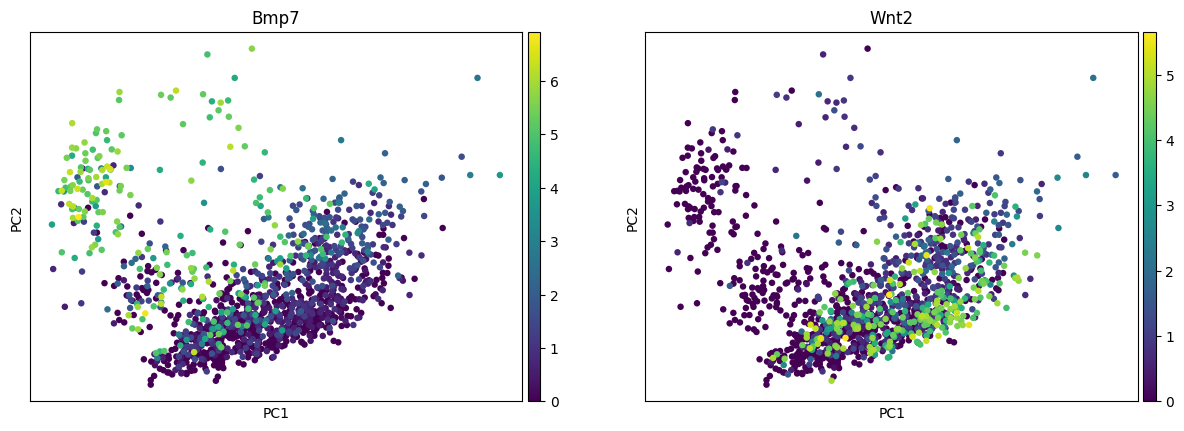

In [2]:
adata = load_fibroblast_data()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable", n_comps=50)
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True) # save this for later
sc.pl.pca_scatter(adata, color=["Bmp7", "Wnt2"])

Based on the PCA scree plot, we will be using 8 PC dimensions to fit the archetypes.

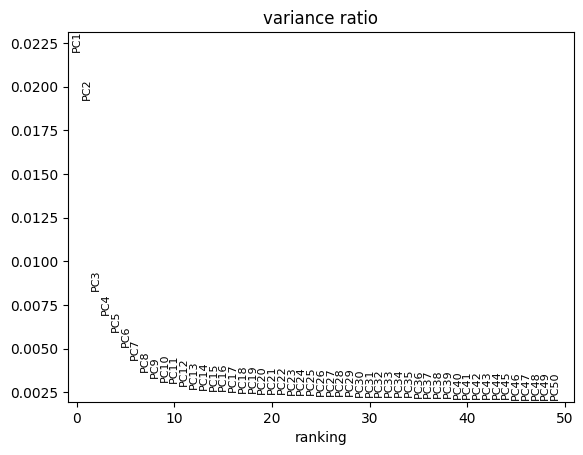

In [3]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=8)

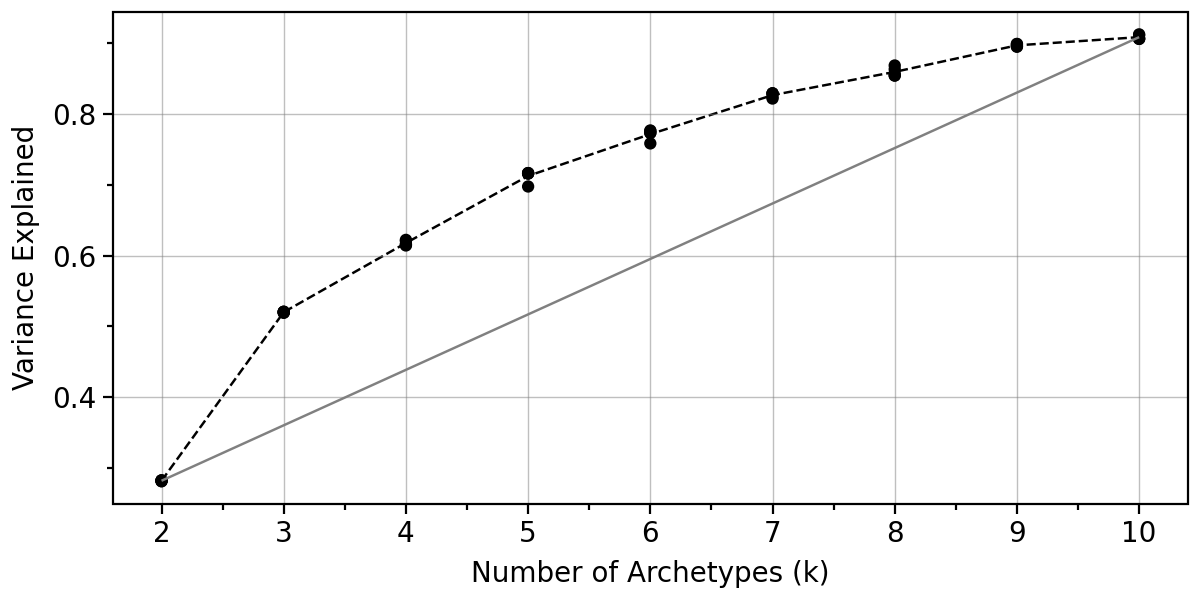

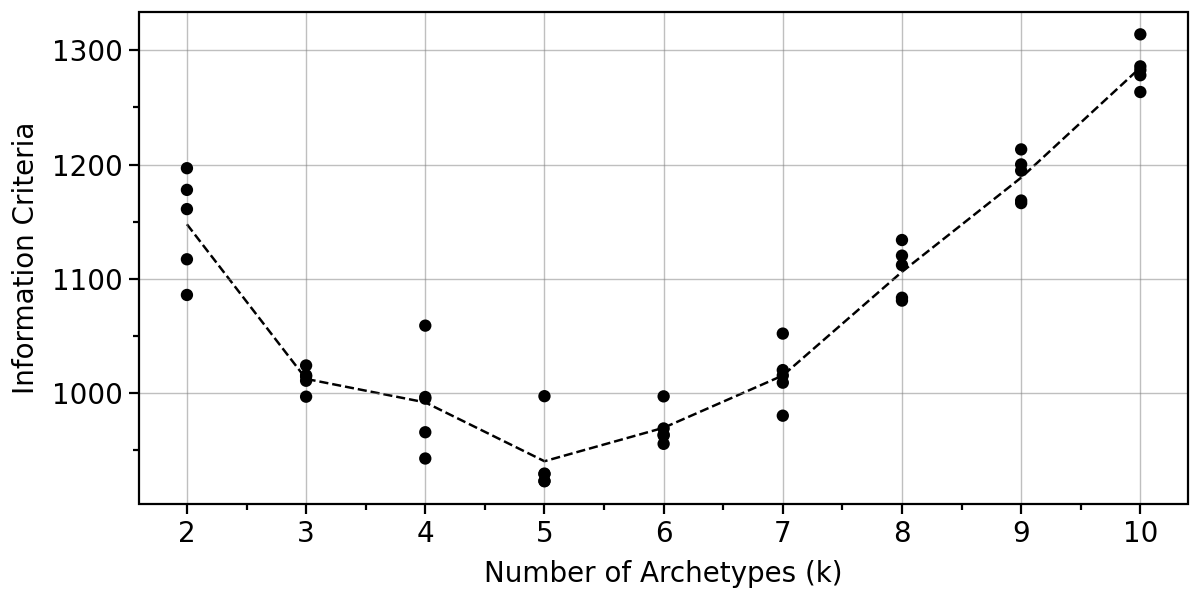

In [4]:
pt.compute_selection_metrics(adata=adata, min_k=2, max_k=10)
pt.plot_var_explained(adata).show()
pt.plot_IC(adata).show()

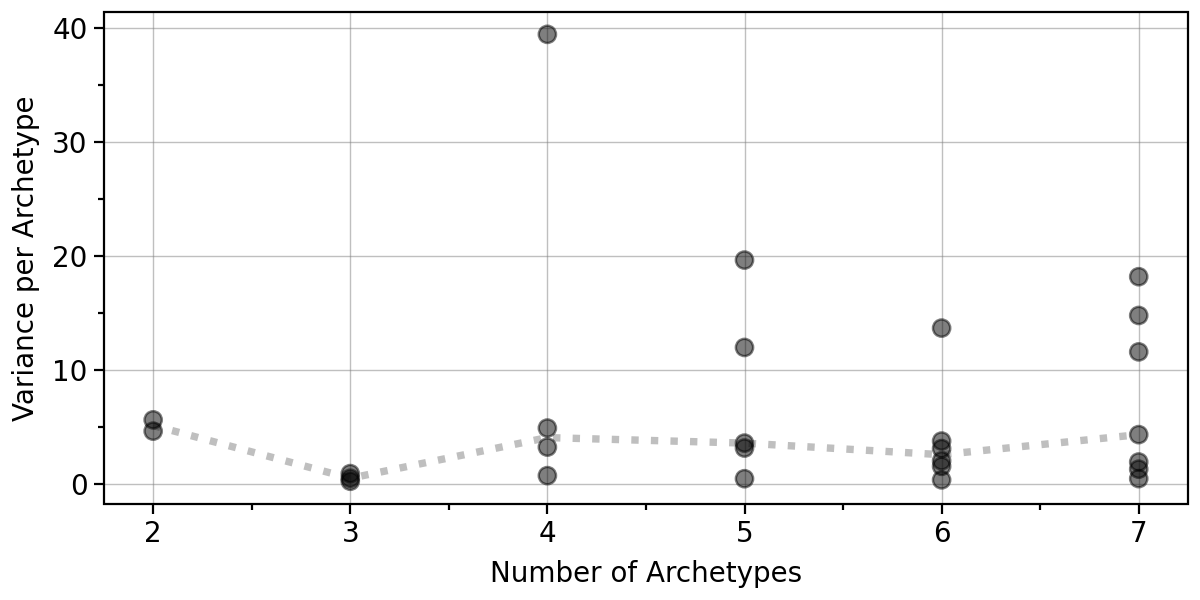

In [5]:
pt.compute_bootstrap_variance(adata, n_bootstrap=30, n_archetypes_list=list(range(2, 8)))
pt.plot_bootstrap_variance(adata)

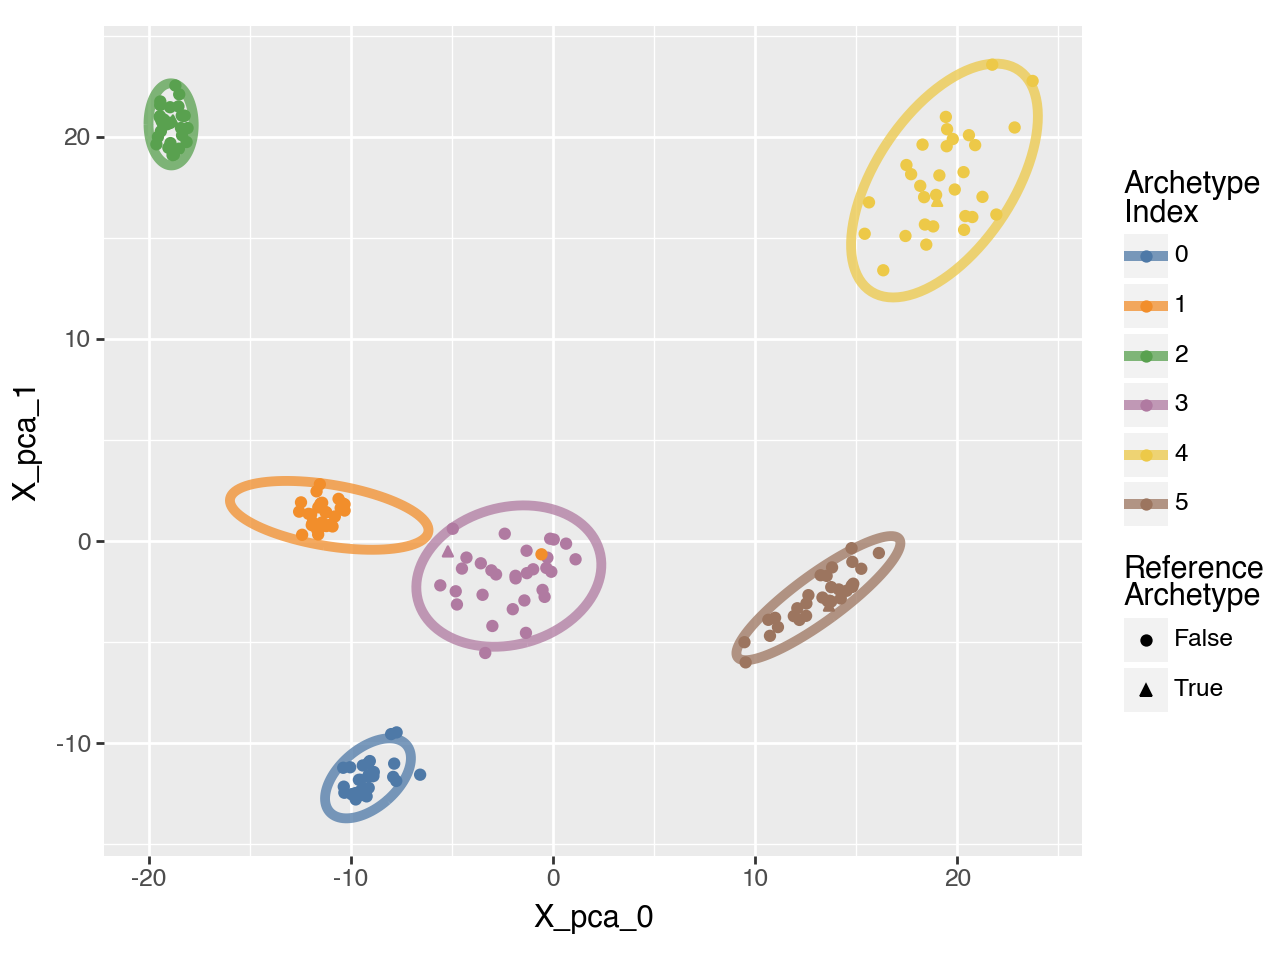

In [6]:
pt.plot_bootstrap_2D(adata, n_archetypes=6)

Here, we will use 5 archetypes. When fitting 4 archetypes we have observed that running archetypal analysis on bootstrapped data shows that one archetype is quite unstable, whereas using 5 worked much better.

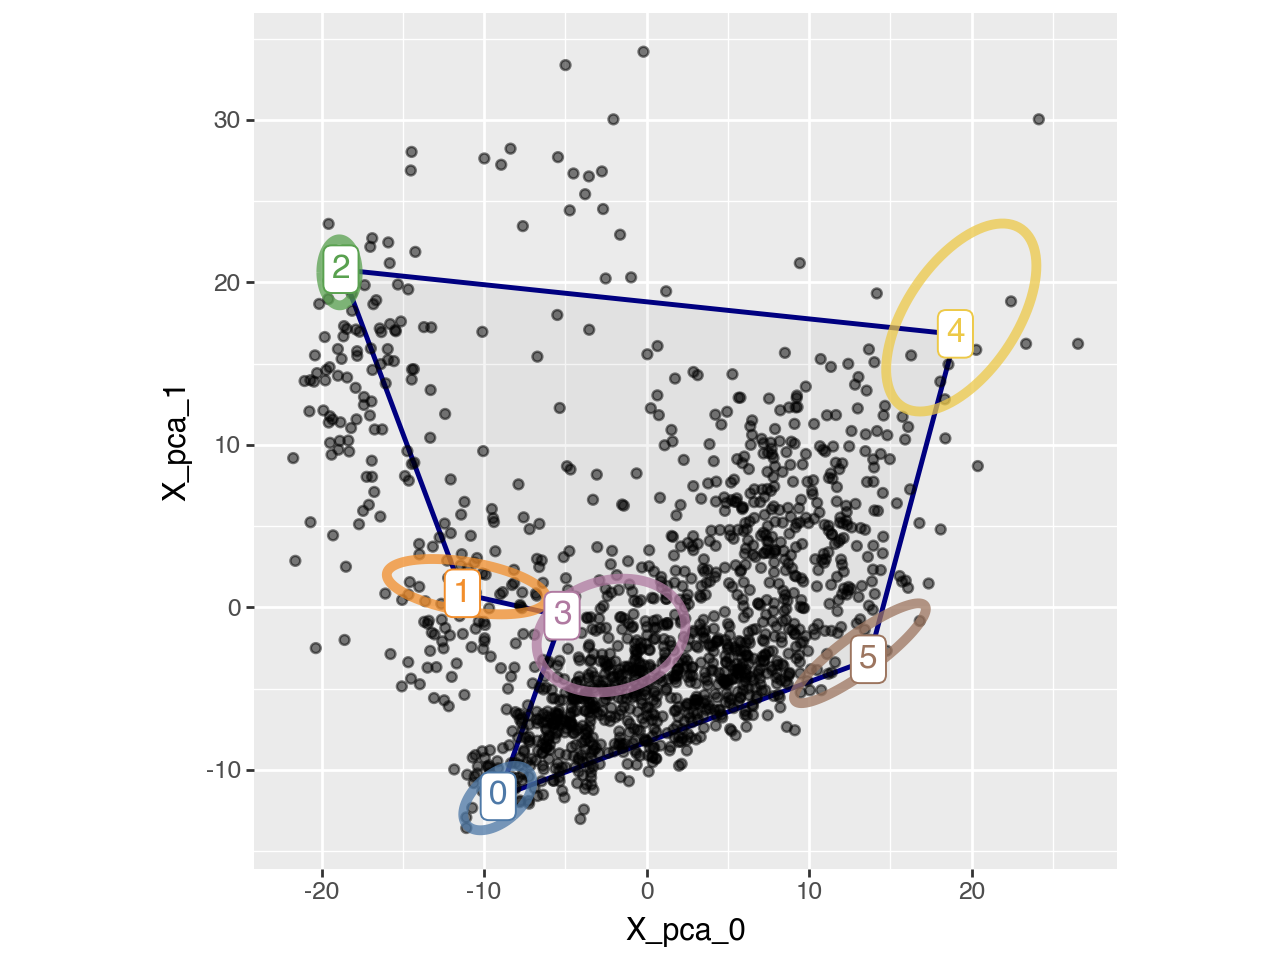

In [7]:
pt.compute_archetypes(adata, n_archetypes=6, verbose=False)
pt.plot_archetypes_2D(adata=adata, show_contours=True)

Determine which genes are characteristic for each archetype

Applied length scale is 12.34.


/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


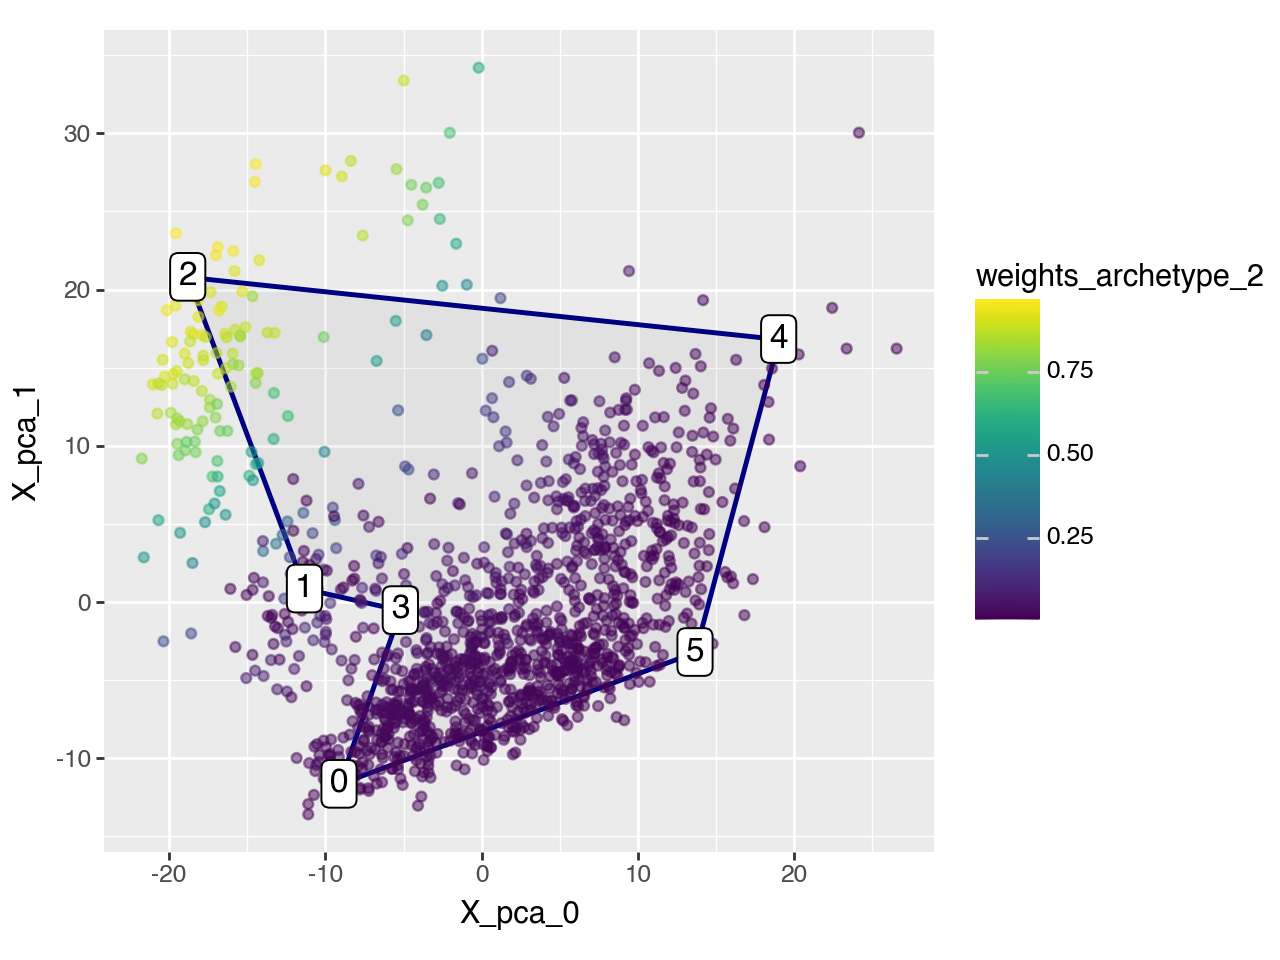

In [8]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
pseudobulk = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

arch_idx = 2
adata.obs[f"weights_archetype_{arch_idx}"] = adata.obsm["cell_weights"][:, arch_idx]
pt.plot_archetypes_2D(adata=adata, color=f"weights_archetype_{arch_idx}")

In [9]:
specific_genes_per_archetype = get_specific_genes_per_archetype(archetype_expression=pseudobulk, min_score=0.05)

[(arch_id, len(arch_genes)) for arch_id, arch_genes in specific_genes_per_archetype.items()]

[(0, 489), (1, 911), (2, 2064), (3, 1793), (4, 6307), (5, 6174)]

Based on the genes we infer the functions of each archetype

In [10]:
for i in range(len(specific_genes_per_archetype)):
    print(i, specific_genes_per_archetype[i].head(25)["gene"].to_list())

0 ['Serping1', 'Bcl6', 'Selenop', 'C1qtnf3', 'Gm16559', 'Ms4a4d', 'Cxcl12', 'Edil3', 'Itm2b', 'Gm15635', 'Mfap4', 'Gm16263', 'Rarres2', 'Gask1b', 'Zfp808', 'Zmynd15', 'Lrrc61', 'Sfrp1', 'Hpse2', 'Fbln1', 'C1rb', 'Sod3', 'Icosl', 'Serpina3n', 'Rax']
1 ['Lmod1', 'Cnn1', 'Actg2', 'Pdgfc', 'Cdh6', 'Itga8', 'Asb2', 'Myocd', 'Kcnmb1', 'Acta1', 'Trpc6', 'Tnfrsf19', 'Slc2a4', 'Hspb7', 'Myh11', 'Tspan2', 'Gm16000', 'Pde6h', 'Tagln', 'Ctxn1', 'Ptk2b', 'Chrdl2', 'Pcp4l1', 'Cacna1h', 'E030013I19Rik']
2 ['Cd38', '1700071M16Rik', 'Nrg1', 'Lef1', 'Lpar3', 'Trpa1', 'Lef1os1', 'Ptprr', 'Pla2g7', 'Rab3b', 'Lama5', 'Cdhr17', 'Ano2', 'Tbx3', 'Glp2r', 'Cd300e', 'C5ar1', 'Ednrb', 'Sema4d', 'Abcc4', 'Col6a4', 'Paqr5', 'Eva1a', 'Insc', 'Plau']
3 ['Efnb2', 'Gm42721', 'Pde1c', 'Gm31258', '1700082M22Rik', 'Gm42785', 'Gm37515', 'Ugcg', 'Gm4117', 'Gm37954', 'Bmp3', 'Gm42513', 'Ryr3', 'Gm43577', 'Gm44153', 'Pkib', 'Kcnq1ot1', 'Gm37086', 'Macrod2os1', 'Ksr2', 'Gm37315', 'Gm42635', 'Mir6240', 'Ddx17', 'Gm17131']
4 ['

In [11]:
archetype_functions = {
    0: "ECM-remodeling fibroblasts",
    1: "Vascular-associated fibroblasts",
    2: "Neuronal/epithelial-interacting fibroblasts",
    3: "Myofibroblasts",
    4: "Immune-modulatory fibroblasts"
}

Finally we use [LIANA+](https://liana-py.readthedocs.io/en/latest/) to infer ligand and receptor are enriched between archetypes.

In [12]:
mouse_resource = li.rs.select_resource("mouseconsensus")
mouse_resource

,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3
...,...,...
35355,Serpina1a,Lrp1
35356,Serpina1b,Lrp1
35357,Serpina1c,Lrp1
35358,Serpina1d,Lrp1


In [13]:
archetype_crosstalk = get_archetype_crosstalk(archetype_genes=specific_genes_per_archetype, 
                                              lr_resource=mouse_resource)
for sender_arch in archetype_crosstalk.keys():
    for receiever_arch in archetype_crosstalk[sender_arch].keys():
        print(f"{sender_arch} -> {receiever_arch}: {len(archetype_crosstalk[sender_arch][receiever_arch])}")
    break

0 -> 0: 3
0 -> 1: 7
0 -> 2: 14
0 -> 3: 3
0 -> 4: 15
0 -> 5: 23


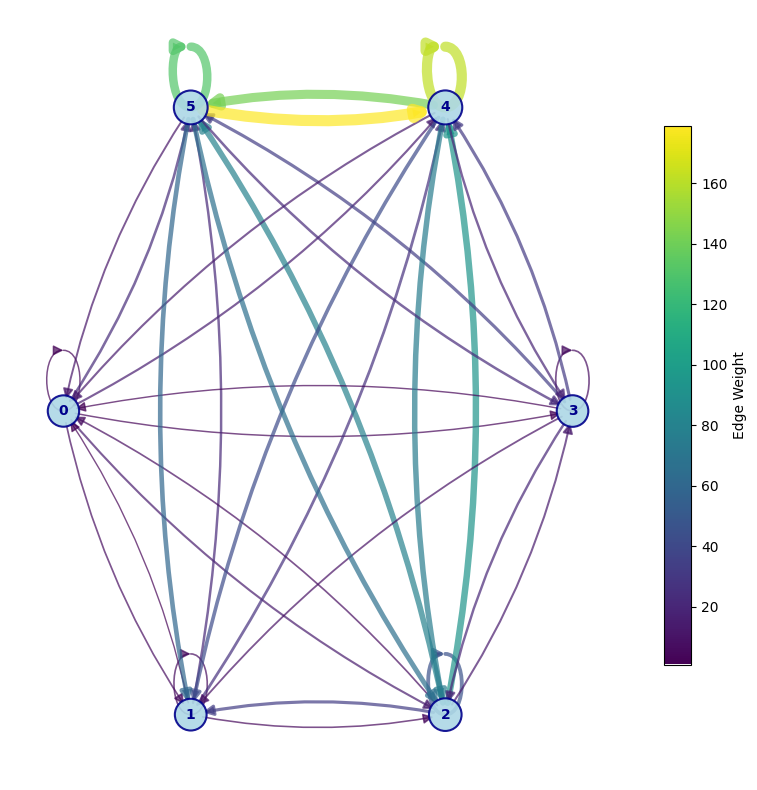

In [14]:
plot_weighted_network(
    specific_genes_per_archetype=specific_genes_per_archetype,
    archetype_crosstalk_dict=archetype_crosstalk,
    layout="shell", 
    seed=42,
    )

## Session Info

In [15]:
import session_info2
print(session_info2.session_info(dependencies=True))

pandas	2.2.3
plotnine	0.14.5
scanpy	1.11.2
liana	1.5.1
partipy	0.0.1
anndata	0.11.4
----	----
appnope	0.1.4
wrapt	1.17.2
python-dateutil	2.9.0.post0
pure_eval	0.2.3
cloudpickle	3.1.1
asttokens	3.0.0
charset-normalizer	3.4.2
toolz	1.0.0
asciitree	0.3.3
jupyter_client	8.6.3
wcwidth	0.2.13
networkx	3.5
urllib3	2.4.0
decorator	5.2.1
numcodecs	0.15.1
pyarrow	20.0.0
traitlets	5.14.3
matplotlib	3.10.3
pyzmq	26.4.0
idna	3.10
pyparsing	3.2.3
dask	2024.11.2
zarr	2.18.7
certifi	2025.4.26 (2025.04.26)
importlib_metadata	8.7.0
platformdirs	4.3.8
patsy	1.0.1
kiwisolver	1.4.8
prompt_toolkit	3.0.51
joblib	1.5.1
attrs	25.3.0
jedi	0.19.2
cattrs	24.1.3
crc32c	2.7.1
numpy	2.2.6
ipykernel	6.29.5
statsmodels	0.14.4
scipy	1.15.2
session-info2	0.1.2
requests-cache	1.2.1
tqdm	4.67.1
numba	0.61.2
future	1.0.0
debugpy	1.8.14
comm	0.2.2
parso	0.8.4
colorama	0.4.6
PyYAML	6.0.2
jupyter_core	5.8.1
natsort	8.4.0
pytz	2025.2
llvmlite	0.44.0
mudata	0.3.2
psutil	7.0.0
requests	2.32.3
docrep	0.3.2
xarray	2024.11.0
plotly